<a href="https://colab.research.google.com/github/vpn12697/localrepo/blob/main/Student_Result_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1-: connect with drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2-: Import Libreries

In [2]:
import numpy as np  # Used for working with array
import pandas as pd # Used for working with data set
import matplotlib.pyplot as plt # Low level graph plotting libreries
import seaborn as sns # High level graph plotting libreries

3-:Load data set

In [3]:
df = pd.read_csv('/content/drive/MyDrive/DATA/Expanded_data_with_more_features.csv')
print(df.head)

<bound method NDFrame.head of        Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType  \
0               0  female         NaN   bachelor's degree      standard   
1               1  female     group C        some college      standard   
2               2  female     group B     master's degree      standard   
3               3    male     group A  associate's degree  free/reduced   
4               4    male     group C        some college      standard   
...           ...     ...         ...                 ...           ...   
30636         816  female     group D         high school      standard   
30637         890    male     group E         high school      standard   
30638         911  female         NaN         high school  free/reduced   
30639         934  female     group D  associate's degree      standard   
30640         960    male     group B        some college      standard   

        TestPrep ParentMaritalStatus PracticeSport IsFirstChild  NrSi

In [4]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572


In [7]:
df = df.drop("Unnamed: 0",axis=1)

In [8]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


Gender distribution

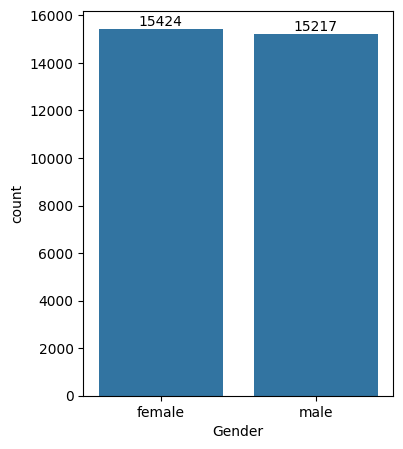

In [12]:
plt.figure(figsize = (4,5))
ax = sns.countplot(data = df, x = 'Gender')
ax.bar_label(ax.containers[0])
plt.show()

From the above graph we can clearly see tha number of female are more as compare to male.


In [13]:
gb = df.groupby('ParentEduc').agg({'MathScore':'mean','ReadingScore':'mean','WritingScore':'mean'})
print(gb)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


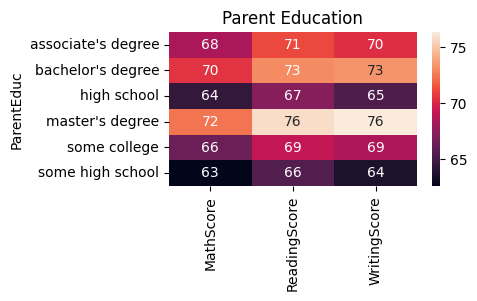

In [24]:
plt.figure(figsize = (4,2))
sns.heatmap(gb, annot =True)
plt.title('Parent Education')
plt.show()

From the above chart we are observing that parents education play a good roll on his kids mark.

In [21]:
gb1 = df.groupby('ParentMaritalStatus').agg({'MathScore':'mean','ReadingScore':'mean','WritingScore':'mean'})
print(gb1)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
divorced             66.691197     69.655011     68.799146
married              66.657326     69.389575     68.420981
single               66.165704     69.157250     68.174440
widowed              67.368866     69.651438     68.563452


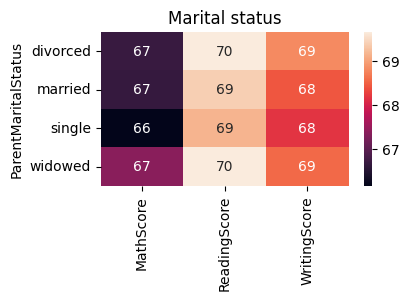

In [23]:
plt.figure(figsize = (4,2))
sns.heatmap(gb1, annot =True)
plt.title('Marital status')
plt.show()

From the above chart we are observing that parent marital status have neglegble impact on his/her kids score.

<Axes: xlabel='MathScore'>

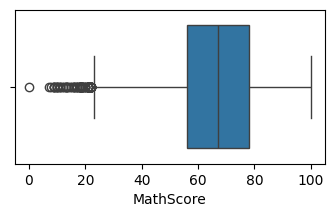

In [26]:
plt.figure(figsize = (4,2))
sns.boxplot(data = df, x ="MathScore")

<Axes: xlabel='ReadingScore'>

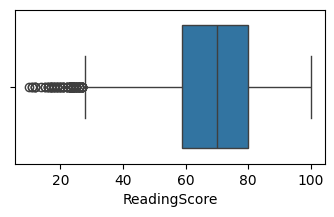

In [27]:
plt.figure(figsize = (4,2))
sns.boxplot(data = df, x ="ReadingScore")

<Axes: xlabel='WritingScore'>

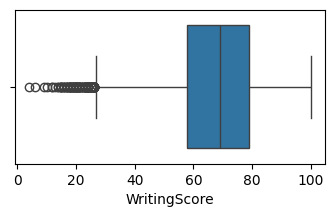

In [28]:
plt.figure(figsize = (4,2))
sns.boxplot(data = df, x ="WritingScore")

In [31]:
print(df["EthnicGroup"].unique())

[nan 'group C' 'group B' 'group A' 'group D' 'group E']


Distribution of EthnicGroup

[2219, 5826, 9212, 7503, 4041]


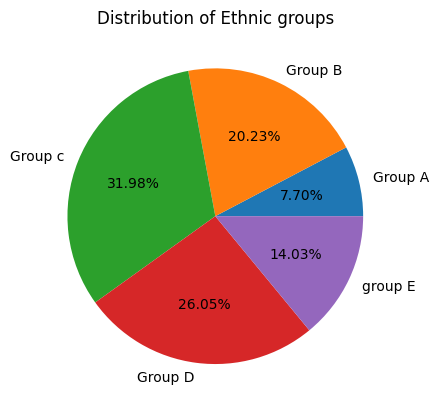

In [40]:
GroupA = df.loc[(df['EthnicGroup'] == 'group A')].count()
GroupB = df.loc[(df['EthnicGroup'] == 'group B')].count()
GroupC = df.loc[(df['EthnicGroup'] == 'group C')].count()
GroupD = df.loc[(df['EthnicGroup'] == 'group D')].count()
GroupE = df.loc[(df['EthnicGroup'] == 'group E')].count()
l = ['Group A','Group B','Group c','Group D','group E']
mlist = [GroupA['EthnicGroup'],GroupB['EthnicGroup'],GroupC['EthnicGroup'],GroupD['EthnicGroup'],GroupE['EthnicGroup']]
print(mlist)
plt.pie(mlist, labels =l, autopct = '%1.2f%%')
plt.title("Distribution of Ethnic groups")
plt.show()
